# Reaction prediction

This notebook helps to understand how reaction outcomes can be predicted over one step. The dataset in use is the training set of the USPTO-MIT (409k; since sampling is needed anyway, npo need for the validation or test set) as obtained here: https://github.com/CC-SXF/DataSet-USPTO 

Sampling was introduced in order to limit the computation time.

1) Load dependencies

In [7]:

import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import DataStructs, rdFingerprintGenerator

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from tqdm import tqdm


2) Load USPTO-MIT data

In [ ]:
# we don't have a header in the txt files, so we specify header=None and provide column names
inputs_df = pd.read_csv(
    "uspto_mit_inputs.txt",
    header=None,
    names=["inputs"]
)


targets_df = pd.read_csv(
    "uspto_mit_targets.txt",
    header=None,
    names=["targets"]
)


# Combine into a single DataFrame
df = pd.concat([inputs_df, targets_df], axis=1)


print("Number of reactions:", len(df))
df.head()

Number of reactions: 409035


,inputs,targets
0,C 1 C C O C 1 . C C ( C ) C [Mg+] . C O N ( C ...,C C ( C ) C C ( = O ) c 1 c c c ( O ) n c 1
1,C N . O . O = C ( O ) c 1 c c c ( Cl ) c ( [N+...,C N c 1 c c c ( C ( = O ) O ) c c 1 [N+] ( = O...
2,C C n 1 c c ( C ( = O ) O ) c ( = O ) c 2 c c ...,C C n 1 c c ( C ( = O ) O ) c ( = O ) c 2 c c ...
3,C C ( C ) = C ( Cl ) N ( C ) C . C O C C ( C )...,C O C C ( C ) O c 1 c c ( O c 2 c n c ( C ( = ...
4,Cl c 1 c c 2 c ( Cl ) n c ( - c 3 c c n c c 3 ...,Cl c 1 c c 2 c ( N C c 3 c c c ( Cl ) c ( Cl )...


In [9]:
df = df.sample(100000, replace=True, random_state=42)
print(len(df))
df.head()

100000


,inputs,targets
121958,C C # N . C C ( C ) N . C S C ( = N C # N ) N ...,C C ( C ) N C ( = N C # N ) N C 1 C C C c 2 c ...
146867,Cl C ( Cl ) ( Cl ) Cl . O C c 1 c c c c ( C C ...,Cl C c 1 c c c c ( C C 2 C C 2 ) c 1
131932,C C ( C ) O C ( = O ) Cl . Cl C Cl . O . [Na+]...,C C ( C ) O C ( = O ) N 1 C C 2 C C ( C N ( C ...
365838,C C ( C ) [Si] ( Cl ) ( C ( C ) C ) C ( C ) C ...,C C ( C ) [Si] ( O C C 1 O C ( n 2 c c c 3 c n...
259178,C 1 C O C C O 1 . C C ( N c 1 n c ( Cl ) c c (...,C C ( N c 1 n c ( N c 2 c n c c n 2 ) c c ( N ...


In [10]:
# Clean whitespaces
df["inputs"] = df["inputs"].str.replace(" ", "", regex=False)

df["targets"] = df["targets"].str.replace(" ", "", regex=False)
df.head()

,inputs,targets
121958,CC#N.CC(C)N.CSC(=NC#N)NC1CCCc2ccccc21,CC(C)NC(=NC#N)NC1CCCc2ccccc21
146867,ClC(Cl)(Cl)Cl.OCc1cccc(CC2CC2)c1.c1ccc(P(c2ccc...,ClCc1cccc(CC2CC2)c1
131932,CC(C)OC(=O)Cl.ClCCl.O.[Na+].[OH-].c1ccc(CN2CC3...,CC(C)OC(=O)N1CC2CC(CN(Cc3ccccc3)C2)C1
365838,CC(C)[Si](Cl)(C(C)C)C(C)C.CN(C)C=O.O.OCC1OC(n2...,CC(C)[Si](OCC1OC(n2ccc3cnccc32)CC1O)(C(C)C)C(C)C
259178,C1COCCO1.CC(Nc1nc(Cl)cc(N2CC(=O)NC(=O)C2)n1)c1...,CC(Nc1nc(Nc2cnccn2)cc(N2CC(=O)NC(=O)C2)n1)c1cc...


3) Reaction featurisation

Combine reactants and reagents, ignore conditions, use MorganFPs.

In [11]:
# helper function 
def smiles_to_fp(smiles, n_bits=2048, radius=2):
    fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    fp = fpgen.GetFingerprint(mol)
    # return fp
    fp_arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    return fp_arr



In [12]:
X = []
y = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    rxn_smiles = str(row["inputs"])
    fp = smiles_to_fp(rxn_smiles)
    
    if fp is None:
        continue
    
    X.append(fp)
    y.append(row["targets"])

X = np.array(X)
y = np.array(y)

print("Usable reactions:", len(X))


  0%|          | 0/100000 [00:00<?, ?it/s][08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom without neighbors
[08:47:11] WARNING: not removing hydrogen atom w

Usable reactions: 99992


4) Convert Products to classification labels

We treat the prediction as multiclass prediction. This assumes that there is **only one product** for one reaction - which is mostly not true for reality. 

In [ ]:
product_to_id = {p: i for i, p in enumerate(sorted(set(y)))} #assign an integer ID to each unique product, we need this id for classes
# for the classification task afterwards, we need to convert the product SMILES strings into integer IDs that the model can predict. 
# This dictionary allows us to do that conversion.
id_to_product = {i: p for p, i in product_to_id.items()}

y_ids = np.array([product_to_id[p] for p in y])

print("Unique products:", len(product_to_id))

Unique products: 86761


5) Train/test split and optional sampling

In [14]:
MAX_SAMPLES = 20000  # set None to use full dataset

if MAX_SAMPLES:
    idx = np.random.choice(len(X), MAX_SAMPLES, replace=False)
    X = X[idx]
    y_ids = y_ids[idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_ids, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 16000
Test size: 4000


6) Define and train ML model.

Using a probabilistic model (e.g. as here: RF) allows us to use effciently evaluation by top-k results and makes interpretation easy.

In [15]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=10,
    min_samples_split=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

/Users/hassanhaydar/DSA104/.venv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:830: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Users/hassanhaydar/DSA104/.venv/lib/python3.12/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Users/hassanhaydar/DSA104/.venv/lib/python3.12/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
/Users/hassanhaydar/DSA104/.venv/lib/python3.12/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is gr

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

7) Top-k accuracy determination

As more reaction paths and therefor multiple different products are possible, looking at one reaction outcome is not very useful.

Instead we are looking at the top-k results for the evaluation. 

In [16]:
def top_k_accuracy(y_true, probs, k):
    top_k = np.argsort(probs, axis=1)[:, -k:]
    return np.mean([
        y_true[i] in top_k[i]
        for i in range(len(y_true))
    ])

In [17]:
probs = model.predict_proba(X_test)

for k in [5, 10, 20, 50]:
    acc = top_k_accuracy(y_test, probs, k)
    print(f"Top-{k} accuracy: {acc:.3f}")

Top-5 accuracy: 0.001
Top-10 accuracy: 0.001
Top-20 accuracy: 0.001
Top-50 accuracy: 0.001


In [21]:
# as seen the accuracy is so bad so the product is not there at all

In [18]:
i = np.random.randint(len(X_test))

true_product = id_to_product[y_test[i]]
top_preds = np.argsort(probs[i])[-5:][::-1]

print("True product:")
print(true_product)

print("\nTop-5 predicted products:")
for pid in top_preds:
    print("-", id_to_product[pid])

True product:
Cc1oc(-c2ccccc2)nc1CCOc1ccc(CC2SC(=O)NC2=O)c2sccc12

Top-5 predicted products:
- CC(C)CC(Sc1ccc(-c2ccc(CN)cc2)cc1)C(=O)NCC#N
- CC(C)CC(OC(c1ccccc1)c1ccc(C(=O)N2CCNCC2)cc1)C(=O)NCC#N
- CC(C)(C=O)c1cccc(C(=O)O)c1
- CC(C)(C)OC(=O)C1C(C#CC(=O)OCC(Cl)(Cl)Cl)C1(C)C
- CC(C)OC(=O)N1CCC(Oc2ncnc(Nc3ccc(S(C)(=O)=O)cc3F)c2C2=NCCN2)CC1


In [19]:
from rdkit import Chem
from rdkit.Chem import Draw

def visualise_smiles(smiles_list):
    mols_list=[]
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        mols_list.append(mol)
        if mol is None:
            print(f"Input {smiles} is not a valid SMILES!")

    img = Draw.MolsToGridImage(
        mols_list,
        subImgSize=(300,300)
    )
    
    return img

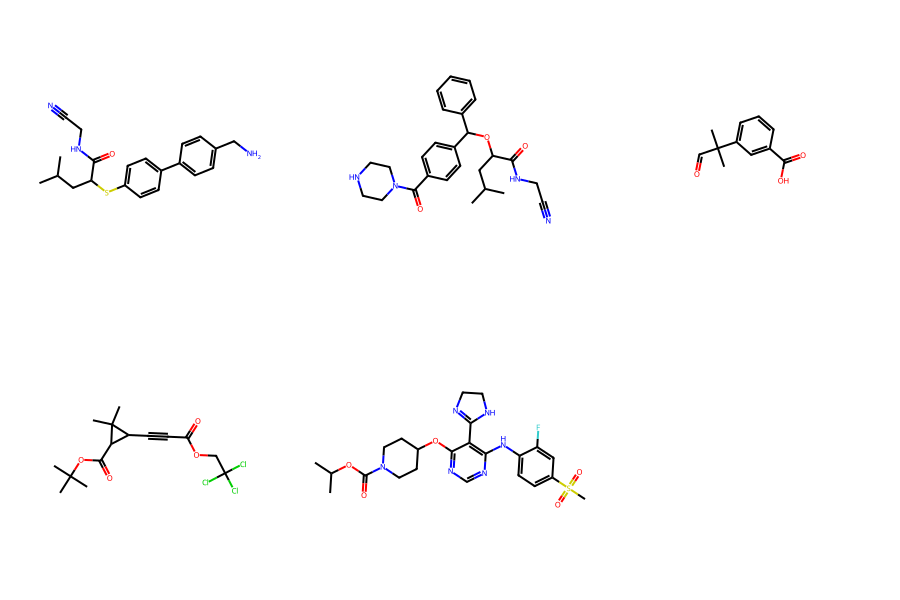

In [20]:
smiles_list= ["CC(C)CC(Sc1ccc(-c2ccc(CN)cc2)cc1)C(=O)NCC#N",
               "CC(C)CC(OC(c1ccccc1)c1ccc(C(=O)N2CCNCC2)cc1)C(=O)NCC#N",
               "CC(C)(C=O)c1cccc(C(=O)O)c1",
               "CC(C)(C)OC(=O)C1C(C#CC(=O)OCC(Cl)(Cl)Cl)C1(C)C",
               "CC(C)OC(=O)N1CCC(Oc2ncnc(Nc3ccc(S(C)(=O)=O)cc3F)c2C2=NCCN2)CC1"]
visualise_smiles(smiles_list)


9) Discussion

- How would other tasks be done (e.g. yield prediction)?
- Why are the top-k accuracies super low?
- we don't give the system enough information, the unique products are =86761 see above in code, this means our data is so sparse, the task is complex so we need to specify another classification task to get better results.
- the model is very simple for it
- What could be done to improve this predictor?
- What experimental information is missing?
- everything a lot of info nothing in data provided
- How would this model be used inside a synthesis planner?

